# ⚙️ 第 74 课 · Ascend C 算子编程:给 AI Core 排数据流水

> 不再问『每个线程干什么』,而是排『数据怎么搬、分成几份、矢量单元怎么算』的流水班表

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 Ascend C 的定位:面向昇腾的算子开发语言,『矢量编程』范式
- 掌握算子开发四要素:数据搬运、矢量计算、流水同步、内存管理
- 看懂『分块搬入 → 片内计算 → 搬出』的数据流,并用 torch 模拟
- 对照 CUDA kernel,理解『线程视角 vs 数据流视角』的差异
- 跑通配套 App:拖动向量长度与分块大小观察流水参数

## 📑 本课目录

1. **直觉:给 AI Core 排班表** — 从『线程在干什么』到『数据怎么流』
2. **矢量编程范式** — 迭代器 + 数据搬运 + 矢量指令 + 流水的四要素
3. **真机模拟:向量加流水** — torch 分块实现 vector add,验证正确性
4. **数据流全图** — HBM → L1/L0 → Vector → 写回 的 matplotlib 示意图
5. **CUDA kernel vs Ascend C** — 两种编程视角的逐项对照表
6. **算子开发流程** — 从算子定义到进算子库的一站式路径
7. **配套 Streamlit 演示** — app_74_ascend_c.py:算子数据流交互

## 🔗 参考资料

- [昇腾 CANN Ascend C 编程指南](https://www.hiascend.com/document)
- [昇腾社区官网](https://www.hiascend.com)
- [MindSpore 官方文档](https://www.mindspore.cn)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:给 AI Core 排班表 🗓️

写 **CUDA kernel** 时,你心里想的是"我有 1000 万个线程,每个线程处理一个元素"——
这是**线程视角**。

写 **Ascend C** 时,你要换一种思路:昇腾的矢量单元一次吃一条向量,你的活儿是安排
**数据流水** —— 把全局内存(HBM)的数据**分块搬进**片内(L1 → L0),喂给矢量单元算,
再把结果**搬出去**。这是**数据流视角**,就像流水线班长排班:

1. **数据搬运**(DataCopy):把一整块数据从 HBM 搬进 L1/L0;
2. **矢量计算**(Vector 指令):对这块数据做 Add / Exp / 激活等;
3. **流水同步**:确保"搬入的没算完,下一块别来抢";
4. **内存管理**:片上缓冲(LocalTensor)的申请与回收。

多块数据之间还能**流水重叠**:第 1 块在算的时候,第 2 块已经在搬了 —— 搬运与计算
并行,这才是昇腾算子高性能的秘密。

## 2️⃣ 矢量编程范式:一次一向量 📐

Ascend C 的核心概念是 **Tensor + Iterator**:

- **GlobalTensor**(全局视角):指向 HBM 中的数据,像仓库的库存清单;
- **LocalTensor**(片上视角):指向 L1/L0 里的数据,像厨房操作台上的菜;
- 算子逻辑 = 用迭代器按块把 GlobalTensor 的数据搬进 LocalTensor,做矢量计算,再搬回。

一个典型的矢量加算子,骨架长这样(真实 Ascend C 语法,仅供理解结构):
```cpp
// Ascend C 伪代码风格:矢量加 VectorAdd
void VectorAdd(GM_ADDR x, GM_ADDR y, GM_ADDR z, int len) {
    GlobalTensor<float> gx, gy, gz;      // 全局张量(仓库)
    LocalTensor<float> lx, ly, lz;       // 片上张量(操作台)
    int block = 1024;                    // 分块大小
    for (int i = 0; i < len / block; i++) {
        DataCopy(lx, gx[i * block], block);   // ① 搬入 A 分块
        DataCopy(ly, gy[i * block], block);   // ① 搬入 B 分块
        Add(lz, lx, ly, block);               // ② 矢量计算
        DataCopy(gz[i * block], lz, block);   // ③ 搬出结果
        sync_all();                           // ④ 流水同步
    }
}
```
注意这里**没有线程、没有 block/grid**,只有"一块一块搬、一块一块算"。下面用 torch
把这条流水线跑一遍(本机无昇腾,模拟数据流逻辑):

✅ 验证:不同分块大小下,分块矢量加与整体加法结果完全一致 —— 分块只是调度方式,不影响数学结果。

In [2]:
def vec_add_pipelined(a, b, block):
    """模拟 Ascend C 矢量加:按 block 分块,每块走一遍 搬入→算→搬出。"""
    n = a.numel()
    out = torch.empty_like(a)
    for s in range(0, n, block):
        e = min(s + block, n)
        out[s:e] = a[s:e] + b[s:e]      # 搬入 lx/ly → Add → 搬出到 lz
    return out

a = torch.randn(1_000_000); b = torch.randn(1_000_000)
for block in [1_000, 10_000, 100_000, 500_000]:
    out = vec_add_pipelined(a, b, block)
    ok = torch.allclose(out, a + b)
    n_blocks = (a.numel() + block - 1) // block
    print(f"block={block:>7,}: 循环 {n_blocks} 次, 结果一致 = {ok}")

block=  1,000: 循环 1000 次, 结果一致 = True
block= 10,000: 循环 100 次, 结果一致 = True
block=100,000: 循环 10 次, 结果一致 = True
block=500,000: 循环 2 次, 结果一致 = True


📊 真实曲线:block 太小(循环次数爆增)时调度开销占主导,耗时上升;block 接近全长时退化为整体加法 —— 昇腾上选 block 同样要避开这两端。

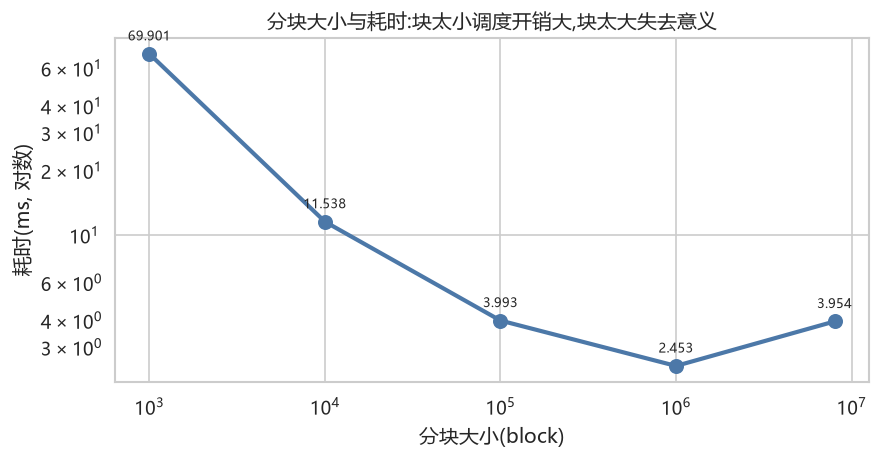

In [3]:
a = torch.randn(8_000_000); b = torch.randn(8_000_000)
def bench(fn, iters=10):
    ts = time.perf_counter()
    for _ in range(iters):
        fn()
    return (time.perf_counter() - ts) / iters * 1000

results = []
for block in [1_000, 10_000, 100_000, 1_000_000, 8_000_000]:
    t = bench(lambda: vec_add_pipelined(a, b, block))
    results.append((block, t))

blocks = [r[0] for r in results]; times = [r[1] for r in results]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(blocks, times, "o-", color="#4C78A8", lw=2.5, ms=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("分块大小(block)"); ax.set_ylabel("耗时(ms, 对数)")
ax.set_title("分块大小与耗时:块太小调度开销大,块太大失去意义")
for bx, ty in zip(blocks, times):
    ax.annotate(f"{ty:.3f}", (bx, ty), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()

## 3️⃣ 数据流全图:搬进去,算完再搬出来 🎨

把一次矢量算子的数据流画成图 —— 注意,整条链路上**中间结果永远在片内**,
只有输入输出碰 HBM,这就是『访存优化』的精髓:

🎨 数据流图:蓝色是搬入路径,绿色是计算,红色是写回 —— 中间结果全程不出片内,这是昇腾算子高性能的根基。

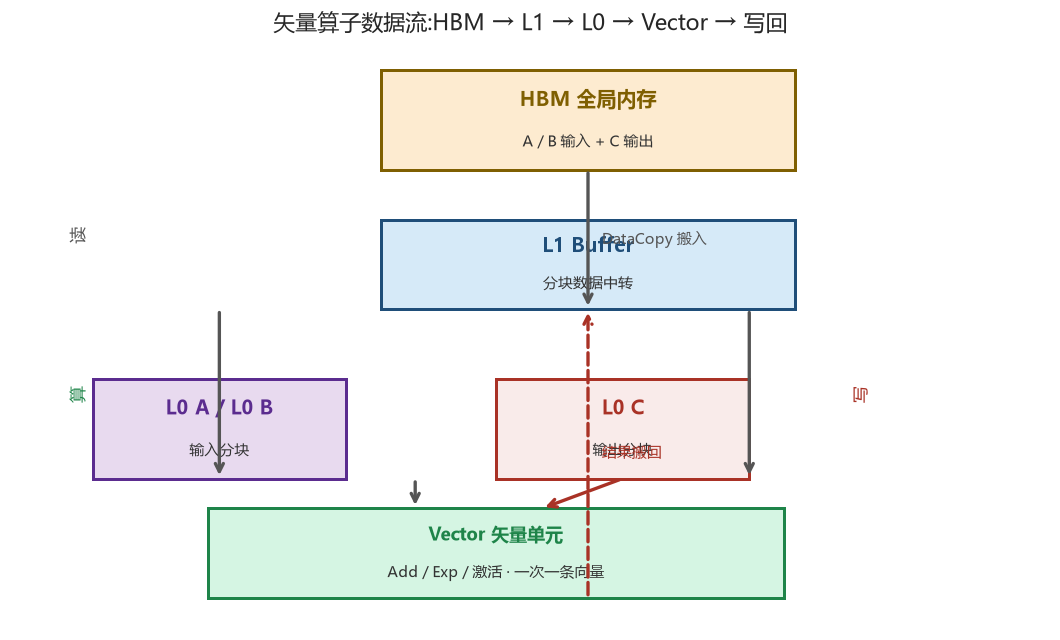

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axis("off")

def box(x, y, w, h, fc, ec, title, sub, tw=12, fs=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.8))
    ax.text(x + w/2, y + h*0.7, title, ha="center", va="center", fontsize=tw,
            fontweight="bold", color=ec)
    ax.text(x + w/2, y + h*0.28, sub, ha="center", va="center", fontsize=fs, color="#333")

def flow(x, y0, y1, color="#555", ls="-", text=""):
    ax.annotate("", xy=(x, y1), xytext=(x, y0),
                arrowprops=dict(arrowstyle="->", lw=2, color=color, linestyle=ls))
    if text:
        ax.text(x + 0.12, (y0 + y1) / 2, text, fontsize=9, color=color, va="center")

box(3.2, 4.3, 3.6, 1.0, "#fdebd0", "#7f5f01", "HBM 全局内存", "A / B 输入 + C 输出")
box(3.2, 2.9, 3.6, 0.9, "#d6eaf8", "#1f4e79", "L1 Buffer", "分块数据中转")
box(0.7, 1.2, 2.2, 1.0, "#e8daef", "#5b2c8f", "L0 A / L0 B", "输入分块")
box(4.2, 1.2, 2.2, 1.0, "#f9ebea", "#a93226", "L0 C", "输出分块")
box(1.7, 0.0, 5.0, 0.9, "#d5f5e3", "#1e8449", "Vector 矢量单元", "Add / Exp / 激活 · 一次一条向量", tw=11)

flow(5.0, 4.3, 2.9, text="DataCopy 搬入")
flow(1.8, 2.9, 1.2)
flow(6.4, 2.9, 1.2)
flow(3.5, 1.2, 0.9)
ax.annotate("", xy=(4.6, 0.9), xytext=(5.3, 1.2),
            arrowprops=dict(arrowstyle="->", lw=2, color="#a93226"))
flow(5.0, 0.0, 2.9, color="#a93226", ls="--", text="结果搬回")
ax.text(0.5, 3.6, "读", fontsize=10, color="#555", rotation=90)
ax.text(0.5, 2.0, "算", fontsize=10, color="#1e8449", rotation=90)
ax.text(7.3, 2.0, "写", fontsize=10, color="#a93226", rotation=90)
ax.set_xlim(0, 9); ax.set_ylim(-0.3, 5.6)
ax.set_title("矢量算子数据流:HBM → L1 → L0 → Vector → 写回", fontsize=13)
plt.tight_layout()

## 4️⃣ CUDA kernel vs Ascend C:两种编程视角 ⚖️

同一件"向量加"的事,两种语言两种问法:

| 维度 | CUDA kernel | Ascend C |
|------|-------------|----------|
| 核心问题 | 每个线程干什么? | 数据怎么搬、怎么分块算? |
| 并行单元 | thread / block / grid | 迭代器按块取数,矢量单元算 |
| 数据搬运 | 显式 global → shared(可选) | 显式 DataCopy: HBM → L1/L0 |
| 计算表达 | 逐元素循环 + 线程下标 | 调用矢量指令(Add、Muls、Exp) |
| 同步 | __syncthreads() | 流水同步 + 屏障 |
| 调度重点 | 线程块布局与 occupancy | 分块大小与流水重叠 |
| 上手难度 | 线程思维直观 | 数据流思维需要转换 |

一句话:**CUDA 把并行交给"人海战术"(海量线程),Ascend C 把并行交给"流水线"**。
二者殊途同归 —— 都是把"搬数据"与"算数据"重叠起来,榨干内存带宽。

## 5️⃣ 算子开发全流程:从函数到算子库 🏭

在昇腾上交付一个算子,大致走五步(概念性描述,无昇腾环境不实际执行):

1. **算子定义**:声明算子名、输入输出数量与类型(Ascend C 的 `RegisterOp`);
2. **Shape 推导**:写 `InferShape` 函数,告诉图引擎"输出张量长什么样";
3. **内核实现**:用 Ascend C 实现矢量/矩阵逻辑,并做流水调度;
4. **编译注册**:用 `msopgen` / `ascendc` 工具编译,把算子注册进算子库;
5. **图融合适配**:让图引擎 GE 能把新算子与相邻算子做融合(第 79 课详讲)。

写好的算子可以直接在 MindSpore / PyTorch(经适配)的模型里调用 —— 这就是昇腾生态
"自研算子"的标准路径。下一课,我们跳到上层,看 MindSpore 框架本身。

## 6️⃣ 配套 Streamlit 演示:算子数据流交互 🎛️

运行同目录下的 `app_74_ascend_c.py`,可以**拖动向量长度与分块大小**,实时看流水段数、
每段字节数、总访存量,并观察段数随分块大小的变化曲线:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_74_ascend_c.py
```

浏览器打开 **http://localhost:8501**。建议把分块从 1,000 一路拖到 500,000,观察流水段数
从"万"量级掉到"十"量级 —— 体会『块太小调度爆炸、块太大片上放不下』的权衡。完整源码
如下(与同目录 `app_74_ascend_c.py` 一字不差):

📜 运行本 cell 会覆盖写入 `app_74_ascend_c.py`,保证 notebook 与 app 始终一致。

In [5]:
%%writefile app_74_ascend_c.py
# -*- coding: utf-8 -*-
# app_74_ascend_c.py — Ascend C 算子数据流交互 ⚙️
import streamlit as st
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="Ascend C 算子数据流 ⚙️", layout="wide")
st.title("⚙️ 第 74 课 · Ascend C 算子编程:数据流交互")

st.markdown("""
Ascend C 是昇腾的算子开发语言。写算子时你不必关心"每个线程干什么",而要安排**数据流水**:
把全局内存(HBM)的数据**分块搬入**片内 L1/L0 → **矢量单元**计算 → 把结果**搬回**全局内存。
下方拖动**向量长度**与**分块大小**,观察流水被切成了几段、每段多大、总访存量是多少。
""")

n = st.sidebar.slider("向量长度(元素数)", 1_000_000, 50_000_000, 10_000_000, 1_000_000)
block = st.sidebar.slider("分块大小(每块元素数)", 1_000, 500_000, 100_000, 1_000)
show_pipeline = st.sidebar.checkbox("展示流水阶段图", value=True)
st.sidebar.caption("分块越大,流水段越少但片上 L1/L0 压力越大;分块越小,循环调度开销越高。")

el_bytes = 4                       # fp32
n_blocks = int(np.ceil(n / block))
block_bytes = block * el_bytes
total_traffic = n * el_bytes * 3   # 读 A + 读 B + 写 C

c1, c2, c3, c4 = st.columns(4)
c1.metric("流水段数(循环次数)", n_blocks)
c2.metric("每段字节数", f"{block_bytes/1024:.0f} KB")
c3.metric("总访存量", f"{total_traffic/1e6:.1f} MB")
c4.metric("调度开销(相对)", f"{n_blocks:.0f}")

if show_pipeline:
    st.subheader("🔁 单段流水:搬入 → 矢量计算 → 搬出")
    stages = ["HBM 读 A", "L1/L0 缓存", "Vector 计算", "写回 HBM"]
    fig = go.Figure()
    for i, s in enumerate(stages):
        fig.add_shape(type="rect", x0=i - 0.35, x1=i + 0.35, y0=0, y1=1,
                      line=dict(color="#2c3e50", width=1.5), fillcolor="#aed6f1")
        fig.add_annotation(x=i, y=0.5, text=s, showarrow=False, font=dict(size=11))
        if i < len(stages) - 1:
            fig.add_annotation(x=i + 0.5, y=0.5, text="→", showarrow=False, font=dict(size=16))
    fig.update_xaxes(showticklabels=False, range=[-0.7, 3.7])
    fig.update_yaxes(showticklabels=False, range=[0, 1.3])
    fig.update_layout(title=f"流水线重复 {n_blocks} 次", height=250,
                      margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig, use_container_width=True)

st.subheader("📊 流水段数随分块大小的变化")
blocks_range = np.geomspace(1_000, 500_000, 40).astype(int)
nseg = [int(np.ceil(n / b)) for b in blocks_range]
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=blocks_range, y=nseg, mode="lines+markers",
                          line=dict(color="#E45756", width=3), name="流水段数"))
fig2.add_vline(x=block, line_dash="dash", line_color="#4C78A8",
               annotation_text=f"当前分块 {block:,}", annotation_position="top right")
fig2.update_layout(xaxis_type="log", title="分块越大,流水段越少(调度开销越低)",
                   xaxis_title="分块大小(对数)", yaxis_title="流水段数", height=360)
st.plotly_chart(fig2, use_container_width=True)
st.caption("⭐ 工程上要在『段数少(省调度)』与『片上放得下(不爆 L1/L0)』之间折中。")

st.markdown("""
> 💡 **结论**:Ascend C 的核心是把『数据搬移 + 计算』编排成流水。段数(N=len/block)越少,
> 越省循环与同步开销;但块太大,片内 L0/L1 放不下就会『溢出搬回』,得不偿失。
""")

Overwriting app_74_ascend_c.py


## ✅ 本课小结

- Ascend C 是昇腾算子开发语言,核心范式是『矢量编程 + 数据流水』
- 算子四要素:数据搬运(DataCopy)、矢量计算、流水同步、内存管理
- 分块(block)是调优主旋钮:块太小调度开销大,块太大片上放不下
- 数据流全图:HBM → L1/L0 → Vector → 写回,中间结果不出片内
- CUDA 是线程视角,昇腾是数据流视角 —— 目标都是重叠『搬』与『算』

## ✍️ 动手练习

1. 把 vec_add_pipelined 改成『向量加再乘 2』(z = (a+b)*2),对比两次操作 vs 一次指令的耗时差异
2. 给数据流图加一条『流水重叠』标注:第 2 块的搬入与第 1 块的计算并行
3. 用 torch 模拟多块流水重叠:提前预取下一块,统计加速比(体会 double-buffer)
4. 查阅 Ascend C 的 sync_all / set_flag / wait_flag 语义,画一张双缓冲同步时序图

## 🔗 延伸阅读

- [昇腾 CANN Ascend C 编程指南](https://www.hiascend.com/document)
- [昇腾社区官网](https://www.hiascend.com)
- [MindSpore 官方文档](https://www.mindspore.cn)

---
> 🎉 恭喜完成本课!下一课见!